In [1]:
import os
import re
import yaml
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
with open("Star_Configurations/current_config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# Example access:
print(cfg["main_star"])

V* RZ Cep


In [3]:
base_dir = Path(cfg["base_dir"])
print("base_dir = "+str(base_dir))

file_object = cfg["file_object"]
print("file_object = "+str(file_object))

main_star = cfg["main_star"]
print("main_star = "+main_star)

base_dir = data
file_object = RZ_Cep
main_star = V* RZ Cep


In [4]:
filter_old = ['Blue', 'Green', 'Red']
filter_new = ['Baader-JC-B', 'Baader-JC-R', 'Baader-JC-V']

print(filter_old, "->", filter_new)

['Blue', 'Green', 'Red'] -> ['Baader-JC-B', 'Baader-JC-R', 'Baader-JC-V']


In [5]:
# Filter a, b and c constants
filter_constants = pd.read_csv("data/filter_transformations.csv")

# Read in data for each old ZWO filter
for filt in filter_old:
    input_path = Path(base_dir) / file_object / filt / "Normilised_stars" / "main_star.csv"
    output_path = Path(base_dir) / file_object / filt / "Normilised_stars" / "main_star_converted.csv"
    
    globals()[f"{filt}_data"] = pd.read_csv(input_path)

# Read in data for each JC filter
filter_new = ['Baader-JC-B', 'Baader-JC-R', 'Baader-JC-V']

# Read in data for each JC filter and assign short names
for filt in filter_new:
    input_path = Path(base_dir) / file_object / filt / "Normilised_stars" / "main_star.csv"
    output_path = Path(base_dir) / file_object / filt / "Normilised_stars" / "main_star_converted.csv"
    
    short_name = filt.split('-')[-1]  # Extract 'B', 'R', or 'V'
    globals()[f"{short_name}_data"] = pd.read_csv(input_path)

In [6]:
# --- Define sinusoidal model ---
def sinusoid(x, A, phi, offset):
    return A * np.sin(2 * np.pi * x + phi) + offset

In [7]:
# --- Helpers to extract date and index from File path ---
def extract_date(file_path):
    # Works for paths like ...\2022_12_07\Light\Blue\...
    match = re.search(r'\\(\d{4}_\d{2}_\d{2})\\Light', file_path)
    return match.group(1) if match else None

def extract_index(file_path):
    # Works for filenames like ..._001_reduced.fits
    match = re.search(r'_(\d+)_reduced\.fits', file_path)
    return match.group(1) if match else None

In [8]:
# --- Pair two filters 1:1 by date + index ---
def pair_filters(m1, m2, mag_col='Source_Mag_norm', err_col='Source_Mag_Error_norm', max_diff_minutes=5):

    df1 = m1.copy()
    df2 = m2.copy()

    # Extract date and index from File column
    df1['date']  = df1['File'].apply(extract_date)
    df1['index'] = df1['File'].apply(extract_index)
    df1['pair_id'] = df1['date'].astype(str) + "_" + df1['index'].astype(str)

    df2['date']  = df2['File'].apply(extract_date)
    df2['index'] = df2['File'].apply(extract_index)
    df2['pair_id'] = df2['date'].astype(str) + "_" + df2['index'].astype(str)
    
    # Align on pair_id
    df1 = df1.set_index('pair_id')
    df2 = df2.set_index('pair_id')
    
    merged = df1.join(df2, how='inner', lsuffix='_1', rsuffix='_2')

    # Convert times to datetime
    merged['time_1'] = pd.to_datetime(merged['time_1'], format='mixed', dayfirst=True, errors='coerce')
    merged['time_2'] = pd.to_datetime(merged['time_2'], format='mixed', dayfirst=True, errors='coerce')
    
    # Drop any rows where times couldn't be parsed
    merged = merged.dropna(subset=['time_1','time_2'])

    # Compute time difference in minutes
    merged['time_diff_min'] = (merged['time_1'] - merged['time_2']).abs().dt.total_seconds() / 60.0

    # Drop pairs with large time differences
    before = len(merged)
    merged = merged[merged['time_diff_min'] <= max_diff_minutes]
    after = len(merged)

    # Average phase from the two filters
    merged['Phase'] = 0.5 * (merged['phase_1'] + merged['phase_2'])

    # Colour = mag1 − mag2
    merged['Colour'] = merged[f'{mag_col}_1'] - merged[f'{mag_col}_2']

    # Error propagation
    merged['Colour_Error'] = np.sqrt(
        merged[f'{err_col}_1']**2 + merged[f'{err_col}_2']**2
    )
 
    return merged[['Phase','Colour','Colour_Error']]

In [9]:
# --- Select filters manually ---
m1, m2 = Blue_data, Green_data
#m1, m2 = Blue_data, Red_data
#m1, m2 = Green_data, Red_data

# --- Extract filter names for labels ---
m1_name = [name for name in globals() if globals()[name] is m1][0].replace('_data', '')
m2_name = [name for name in globals() if globals()[name] is m2][0].replace('_data', '')
colour_label = f'ZWO_{m1_name} - ZWO_{m2_name}'

# --- Pair exposures directly ---
colour_df = pair_filters(m1, m2)

# --- Clean NaNs ---
clean_df = colour_df[np.isfinite(colour_df['Colour']) & np.isfinite(colour_df['Colour_Error'])].copy()
clean_df = clean_df.sort_values('Phase').reset_index(drop=True)

# --- Weighted fit using errors ---
params, cov = curve_fit(
    sinusoid,
    clean_df['Phase'],
    clean_df['Colour'],
    sigma=clean_df['Colour_Error'],
    absolute_sigma=True,
    p0=[0.05, 0, -0.02]
)
A_fit, phi_fit, offset_fit = params
perr = np.sqrt(np.diag(cov))
fitted_colour = sinusoid(clean_df['Phase'], A_fit, phi_fit, offset_fit)

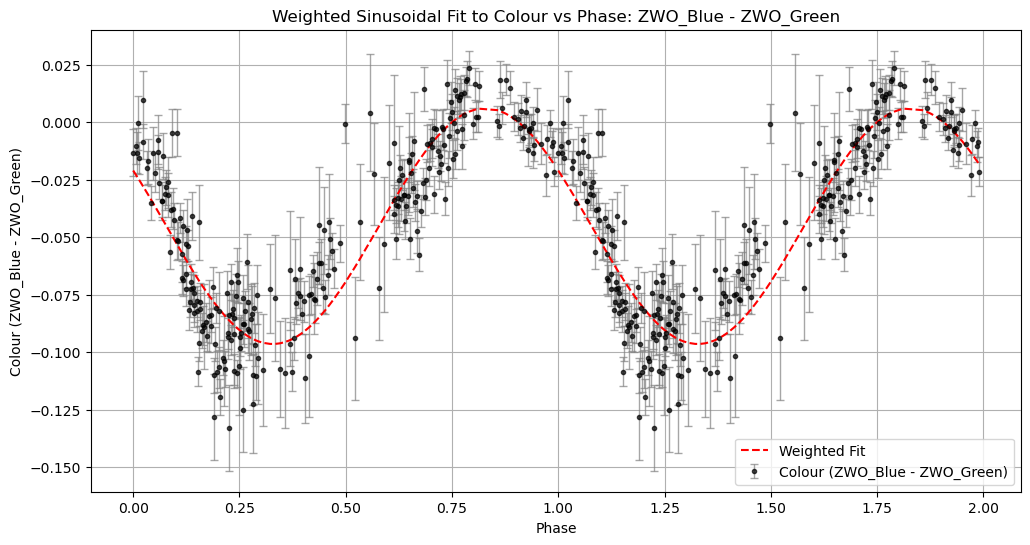

In [18]:
# --- Plot ---
plt.figure(figsize=(12,6))
plt.errorbar(clean_df['Phase'], clean_df['Colour'], yerr=clean_df['Colour_Error'],
             fmt='.', color='k', ecolor='gray', alpha=0.7, capsize=3, elinewidth=1,
             label=f'Colour ({colour_label})')
plt.plot(clean_df['Phase'], fitted_colour, label='Weighted Fit', color='red', linestyle='--')

plt.errorbar(clean_df['Phase']+1, clean_df['Colour'], yerr=clean_df['Colour_Error'],
             fmt='.', color='k', ecolor='gray', alpha=0.7, capsize=3, elinewidth=1)
plt.plot(clean_df['Phase']+1, fitted_colour, color='red', linestyle='--')

plt.xlabel('Phase')
plt.ylabel(f'Colour ({colour_label})')
plt.title(f'Weighted Sinusoidal Fit to Colour vs Phase: {colour_label}')
plt.legend()
plt.grid(True)
plt.show()

# Save to CSV
#save_subset = clean_df[['Phase', 'Colour', 'Colour_Error']]
#save_subset.to_csv(f"data/{file_object}/phase_colour_data.csv", index=False)


# Conversion

In [11]:
def get_colour(df):

    # Evaluate fitted sinusoid at each phase
    df['Colour'] = sinusoid(df['phase'], A_fit, phi_fit, offset_fit)

    # Simple error propagation: use the fit parameter errors as a proxy
    df['Colour_Error'] = np.sqrt(np.sum(perr**2))

    return df['Colour']

In [12]:
def convert_and_plot(df, filter_constants, old_filter, new_filter, plot=False, colour='k'):

    # Stops overwritting stuff, all changes made here are local
    df = df.copy()

    # Get transformation coefficients and their errors
    row = filter_constants[(filter_constants['filter_from'] == old_filter) & (filter_constants['filter_to'] == new_filter)]

    a, b, c     = row['a'].values[0], row['b'].values[0], row['c'].values[0]
    a_err, b_err, c_err = row['a_err'].values[0], row['b_err'].values[0], row['c_err'].values[0]

    # Compute colour from fit at each phase
    colour_index = get_colour(df)

    # Airmass
    airmass = df['Air mass'].astype(float)

    # Apply conversion: M_conv = M_src + a + b*airmass + c*colour
    df['Converted_Mag'] = df['Source_Mag_norm'] + a + (b * airmass) + (c * colour_index)

    # Error propagation:
    src_err = df['Source_Mag_Error_norm'].astype(float)
    col_err = df['Colour_Error'].astype(float)

    df['Converted_Mag_Error'] = np.sqrt(
        src_err**2 +                     # measurement error
        a_err**2 +                       # offset coefficient error
        (airmass**2) * (b_err**2) +      # slope coefficient error
        (colour_index**2) * (c_err**2) + # colour coefficient error
        (c**2) * (col_err**2)            # colour index uncertainty
    )

    # Optional plot
    if plot:
        plt.figure(figsize=(12,6))
        plt.errorbar(df['phase'], df['Converted_Mag'], yerr=df['Converted_Mag_Error'],
                     fmt='.', color=colour, ecolor='gray', alpha=0.6, capsize=2)
        plt.errorbar(df['phase']+1, df['Converted_Mag'], yerr=df['Converted_Mag_Error'],
                     fmt='.', color=colour, ecolor='gray', alpha=0.6, capsize=2)
        plt.xlabel('Phase')
        plt.ylabel(f'Converted Magnitude ({new_filter})')
        plt.title(f'{old_filter} → {new_filter} Conversion')
        plt.grid(True)
        plt.show()

    return df

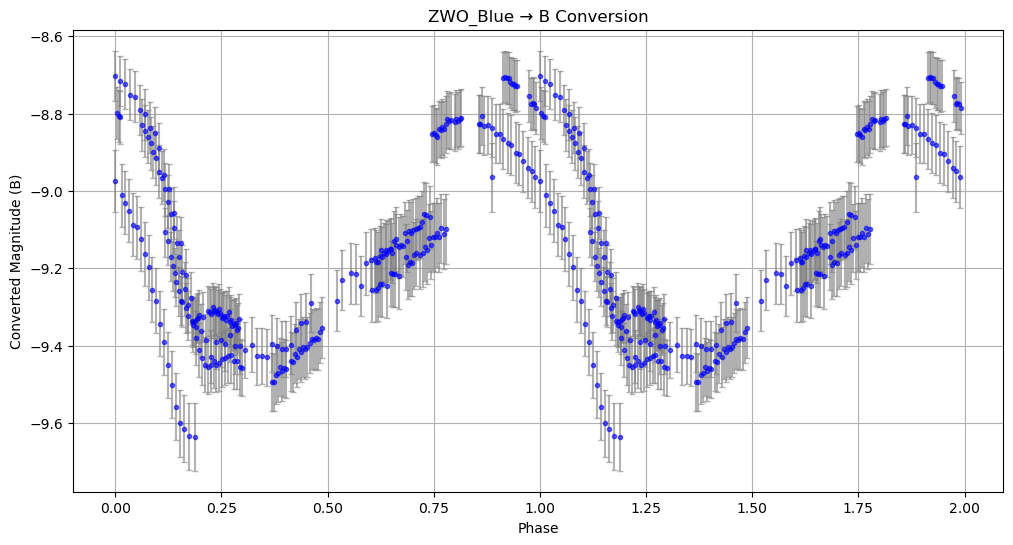

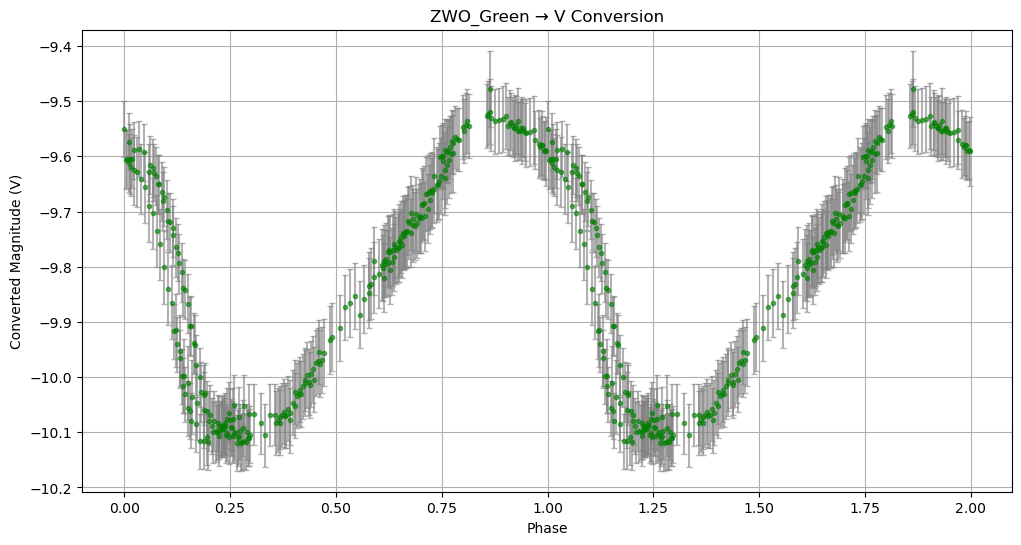

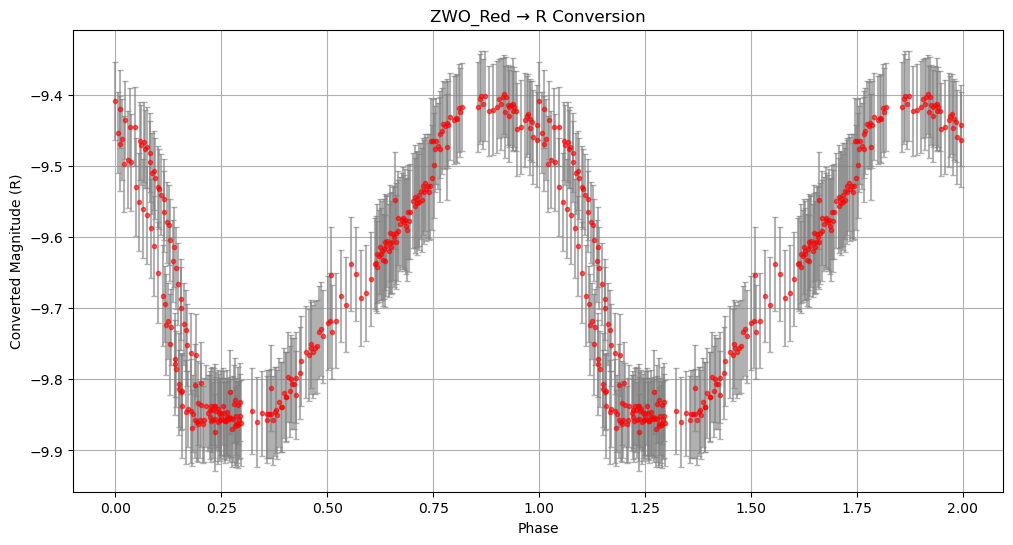

In [13]:
plot = True

Blue_data  = convert_and_plot(Blue_data,  filter_constants, 'ZWO_Blue',  'B', plot, colour='b')
Green_data = convert_and_plot(Green_data, filter_constants, 'ZWO_Green', 'V', plot, colour='g')
Red_data   = convert_and_plot(Red_data,   filter_constants, 'ZWO_Red',   'R', plot, colour='r')

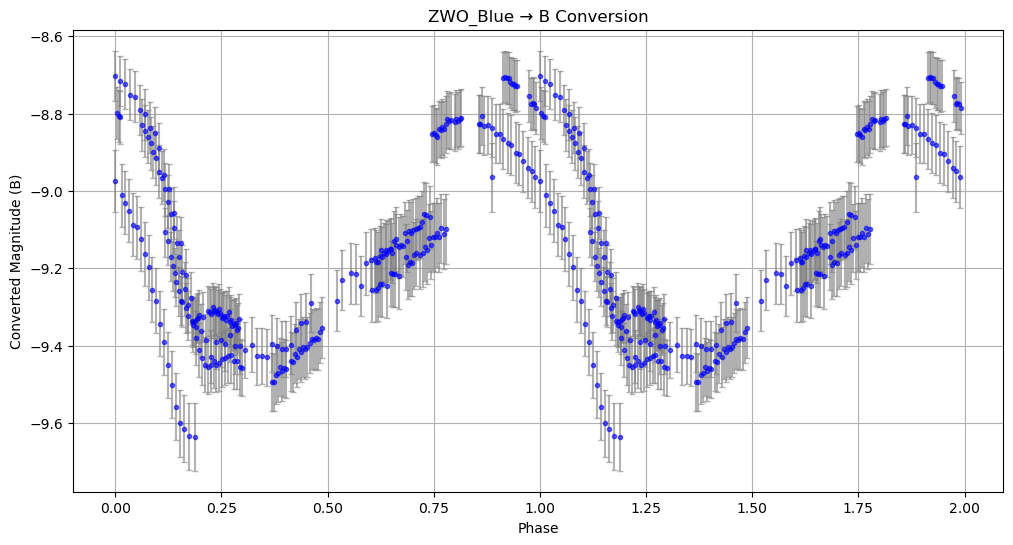

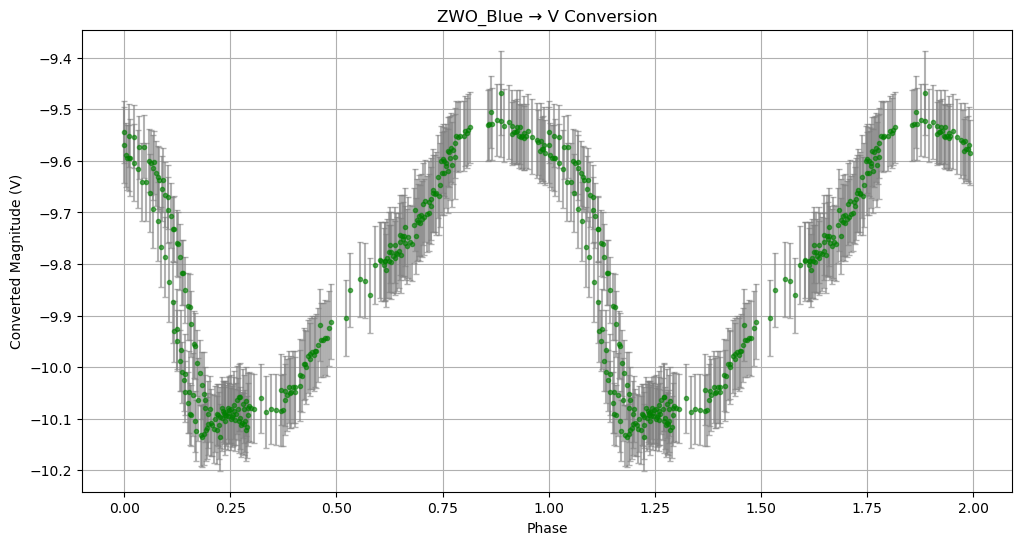

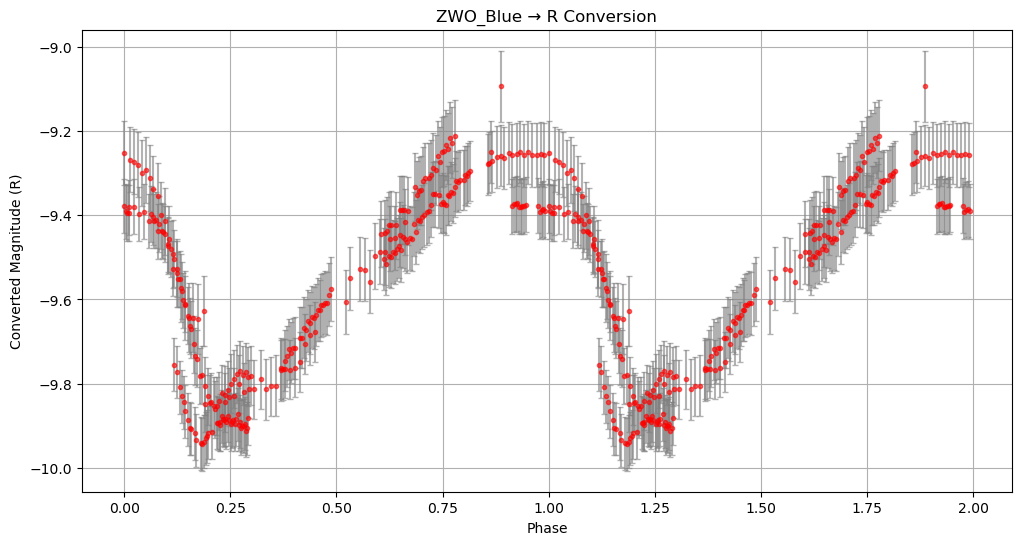

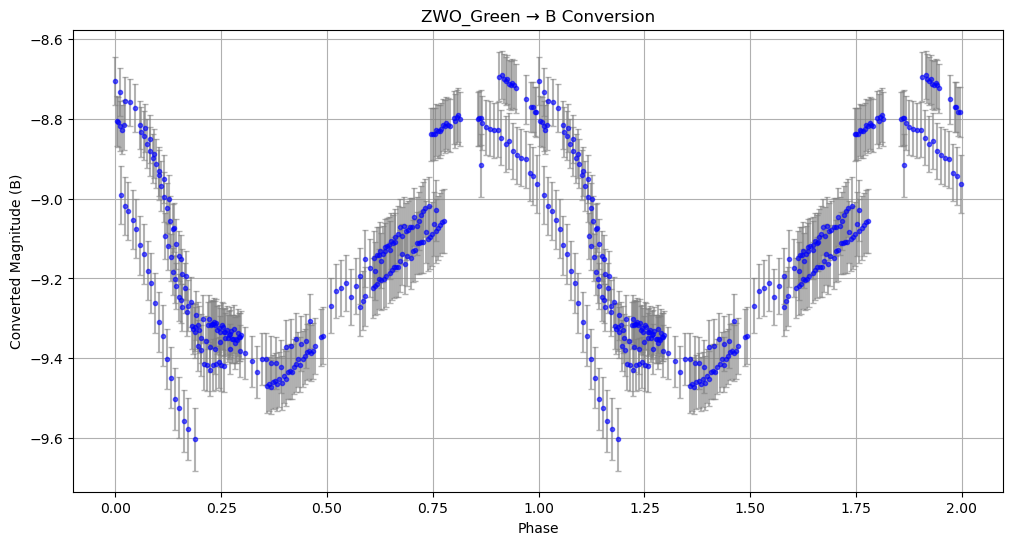

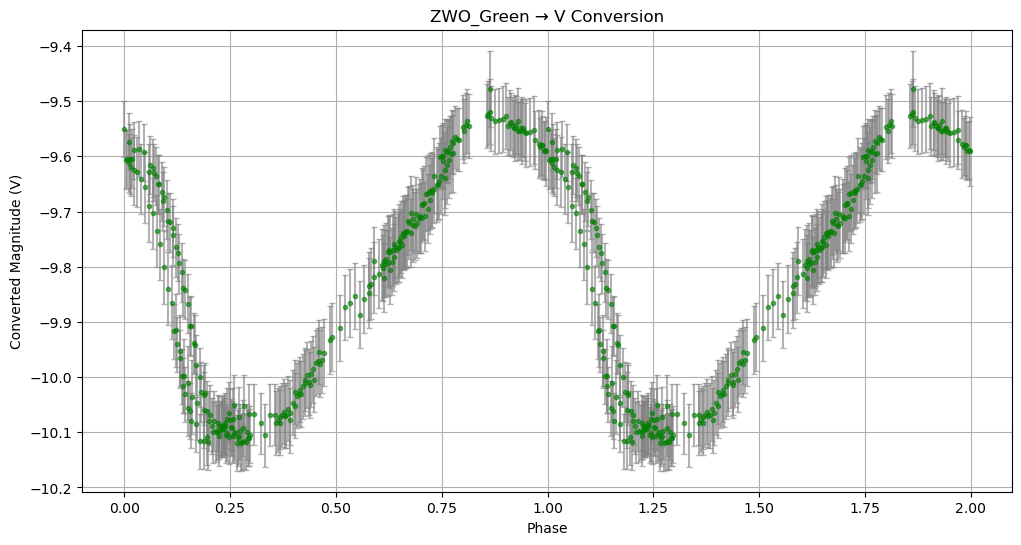

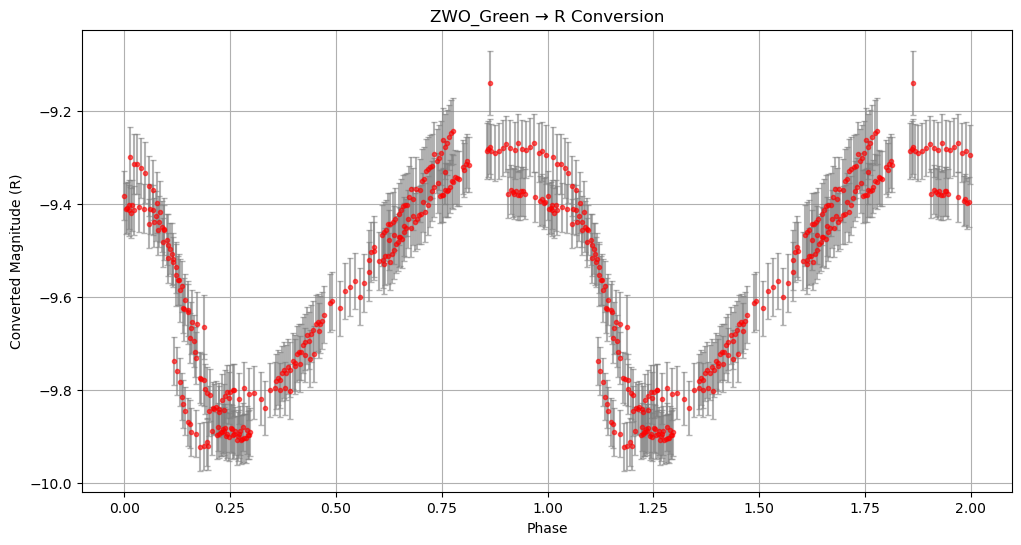

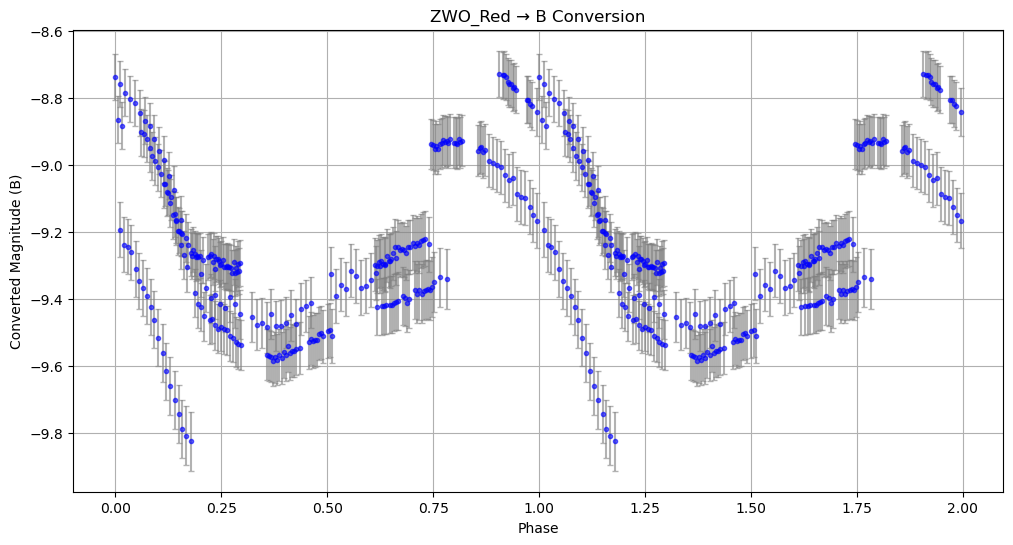

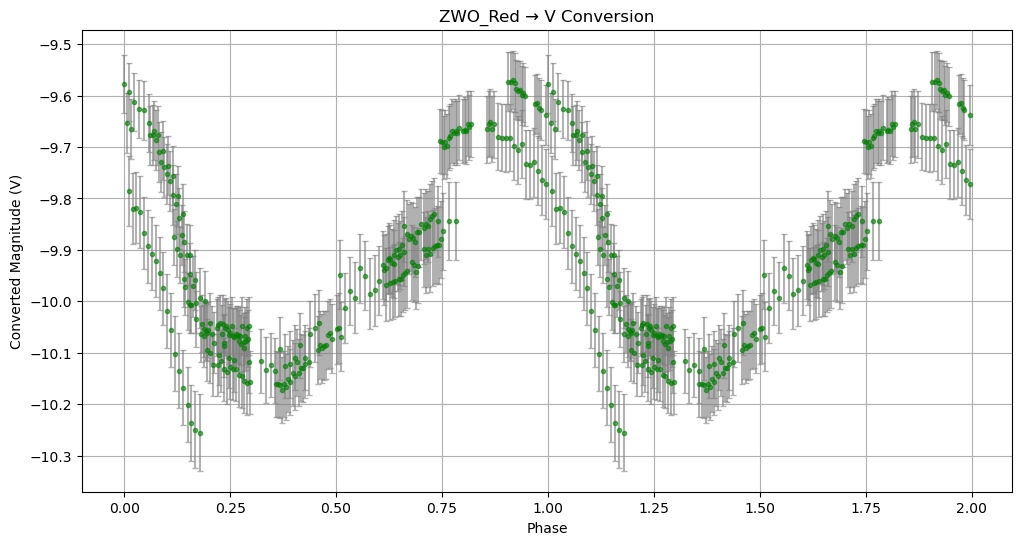

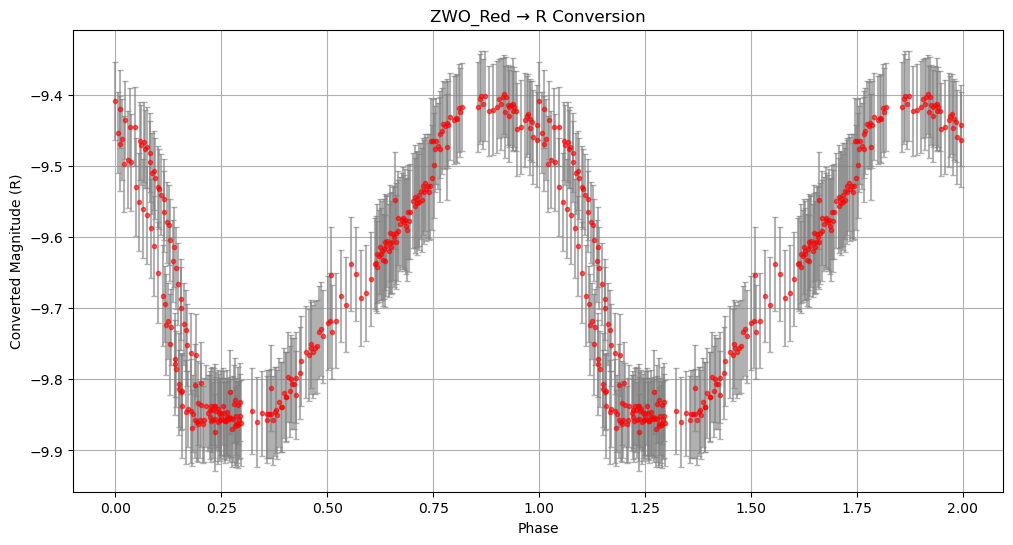

In [14]:
zwo_filters = [
    {"df": Blue_data,  "from": "ZWO_Blue"},
    {"df": Green_data, "from": "ZWO_Green"},
    {"df": Red_data,   "from": "ZWO_Red"},
]

jc_targets = ["B", "V", "R"]
target_colours = {"B": "b", "V": "g", "R": "r"}

# Loop through every combination
for zwo in zwo_filters:
    for target in jc_targets:
        convert_and_plot(
            zwo["df"],
            filter_constants,
            zwo["from"],
            target,
            plot,                        # always show the plot
            colour=target_colours[target]  # colour by target filter
        )